# Data Cleaning and Preprocessing

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('/content/drive/MyDrive/DataScience_Mini_Project/survey.csv')

print("=" * 60)
print("STARTING DATA CLEANING PROCESS")
print("=" * 60)
print(f"Initial dataset shape: {df.shape}")

# ============================================
# STEP 1: Remove unnecessary columns
# ============================================
df_clean = df.drop(['state', 'comments', 'Timestamp'], axis=1)
print(f"\nStep 1 - After removing unnecessary columns: {df_clean.shape}")

# ============================================
# STEP 2: Handle Age outliers
# ============================================
print("\n" + "=" * 40)
print("STEP 2: Age Cleaning")
print("=" * 40)

# Remove unrealistic ages (keep only 18-100 range)
df_clean = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 100)]
print(f"Rows after age filtering: {df_clean.shape[0]}")

# ============================================
# STEP 3: Clean Gender column
# ============================================
print("\n" + "=" * 40)
print("STEP 3: Gender Cleaning")
print("=" * 40)

def clean_gender(gender):
    if pd.isna(gender):
        return 'Other'

    gender = str(gender).lower().strip()

    # Male variations
    if gender in ['male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)',
                  'make', 'male ', 'man', 'msle', 'mail', 'malr', 'cis male',
                  'male leaning androgynous']:
        return 'Male'

    # Female variations
    elif gender in ['female', 'f', 'woman', 'female ', 'cis female',
                    'femake', 'female (cis)', 'femail', 'female (trans)',
                    'cis-female/femme']:
        return 'Female'

    # Everything else goes to Other
    else:
        return 'Other'

df_clean['Gender'] = df_clean['Gender'].apply(clean_gender)
print("Gender distribution after cleaning:")
print(df_clean['Gender'].value_counts())

# ============================================
# STEP 4: Fix no_employees column
# ============================================
print("\n" + "=" * 40)
print("STEP 4: Fixing no_employees Column")
print("=" * 40)

# Define mapping for incorrect values
no_employees_mapping = {
    'Jun-25': '6-25',
    '01-May': '1-5',
    '1-May': '1-5',
    '5-Jan': '1-5',
    '5-May': '1-5',
    '6-May': '6-25',
    '6-Jan': '6-25',
    '26-May': '26-100',
    '26-Jan': '26-100',
    '100-May': '100-500',
    '500-May': '500-1000',
}

# Apply the mapping
df_clean['no_employees'] = df_clean['no_employees'].replace(no_employees_mapping)

# Function to handle any remaining date-like strings
def fix_no_employees_remaining(value):
    if pd.isna(value):
        return value

    value = str(value)

    # Handle 'Jun-25' format (month-day)
    if '-' in value:
        parts = value.split('-')
        if len(parts) == 2 and parts[0].isdigit():
            # Return appropriate format based on number
            num = int(parts[0])
            if num == 1:
                return '1-5'
            elif num == 6:
                return '6-25'
            elif num == 26:
                return '26-100'
            elif num == 100:
                return '100-500'
            elif num == 500:
                return '500-1000'
            else:
                return value
    return value

df_clean['no_employees'] = df_clean['no_employees'].apply(fix_no_employees_remaining)

# Set correct order for company size
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
df_clean['no_employees'] = pd.Categorical(df_clean['no_employees'],
                                           categories=size_order,
                                           ordered=True)

print("no_employees distribution after fixing:")
print(df_clean['no_employees'].value_counts().sort_index())

# ============================================
# STEP 5: Fix Country column
# ============================================
print("\n" + "=" * 40)
print("STEP 5: Fixing Country Column")
print("=" * 40)

# Check for blank/empty values in Country
print("Country values before fixing:")
print(df_clean['Country'].value_counts().head(10))

# Replace '(blank)' with 'Unknown'
df_clean['Country'] = df_clean['Country'].replace('(blank)', 'Unknown')
df_clean['Country'] = df_clean['Country'].fillna('Unknown')

print("\nCountry values after fixing:")
print(df_clean['Country'].value_counts().head(10))

# ============================================
# STEP 6: Fix column name inconsistencies
# ============================================
print("\n" + "=" * 40)
print("STEP 6: Fixing Column Names")
print("=" * 40)

# Rename columns with typos or inconsistencies
column_renames = {
    'phys_health_consequence ': 'phys_health_consequence',  # Remove trailing space
    'cowokers': 'coworkers',  # Fix typo
    'physical_health_interview': 'phys_health_interview',  # Standardize
}

df_clean = df_clean.rename(columns=column_renames)

# Strip whitespace from all column names
df_clean.columns = df_clean.columns.str.strip()

print("Column names after fixing:")
print(df_clean.columns.tolist())

# ============================================
# STEP 7: Standardize categorical values
# ============================================
print("\n" + "=" * 40)
print("STEP 7: Standardizing Categorical Values")
print("=" * 40)

# Strip whitespace from all string columns
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].str.strip()

# Set ordinal categories for work_interfere
work_interfere_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Don\'t know']
df_clean['work_interfere'] = pd.Categorical(df_clean['work_interfere'],
                                            categories=work_interfere_order,
                                            ordered=True)

# Set ordinal categories for leave
leave_order = ['Very difficult', 'Somewhat difficult', 'Don\'t know', 'Somewhat easy', 'Very easy']
df_clean['leave'] = pd.Categorical(df_clean['leave'],
                                   categories=leave_order,
                                   ordered=True)

print("work_interfere categories:")
print(df_clean['work_interfere'].cat.categories.tolist())
print("\nleave categories:")
print(df_clean['leave'].cat.categories.tolist())

# ============================================
# STEP 8: Handle missing values
# ============================================
print("\n" + "=" * 40)
print("STEP 8: Handling Missing Values")
print("=" * 40)

print("Missing values before handling:")
print(df_clean.isnull().sum())

# Fill missing values
df_clean['self_employed'] = df_clean['self_employed'].fillna('No')
df_clean['work_interfere'] = df_clean['work_interfere'].fillna('Don\'t know')
df_clean['Country'] = df_clean['Country'].fillna('Unknown')

print("\nMissing values after handling:")
print(df_clean.isnull().sum())

# ============================================
# STEP 9: Remove duplicates
# ============================================
print("\n" + "=" * 40)
print("STEP 9: Removing Duplicates")
print("=" * 40)

print(f"Duplicate rows before: {df_clean.duplicated().sum()}")
df_clean = df_clean.drop_duplicates()
print(f"Duplicate rows after: {df_clean.duplicated().sum()}")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 60)
print("CLEANING COMPLETE - FINAL SUMMARY")
print("=" * 60)
print(f"Final shape: {df_clean.shape}")
print(f"Final columns: {df_clean.columns.tolist()}")
print(f"\nTotal rows: {df_clean.shape[0]}")
print(f"Total columns: {df_clean.shape[1]}")
print(f"\nMissing values check: {df_clean.isnull().sum().sum()} missing values (should be 0)")

print("\nGender distribution:")
print(df_clean['Gender'].value_counts())

print("\nTreatment distribution:")
print(df_clean['treatment'].value_counts(normalize=True))

print("\nCountry distribution (top 10):")
print(df_clean['Country'].value_counts().head(10))

print("\nwork_interfere distribution:")
print(df_clean['work_interfere'].value_counts())

print("\nno_employees distribution:")
print(df_clean['no_employees'].value_counts().sort_index())

# Save cleaned data
df_clean.to_csv('/content/drive/MyDrive/DataScience_Mini_Project/mental_health_cleaned.csv', index=False)
print("\n Cleaned data saved as 'mental_health_cleaned.csv'")

# Display first few rows
print("\nFirst 5 rows of cleaned data:")
print(df_clean.head())

STARTING DATA CLEANING PROCESS
Initial dataset shape: (1259, 27)

Step 1 - After removing unnecessary columns: (1259, 24)

STEP 2: Age Cleaning
Rows after age filtering: 1251

STEP 3: Gender Cleaning
Gender distribution after cleaning:
Gender
Male      986
Female    249
Other      16
Name: count, dtype: int64

STEP 4: Fixing no_employees Column
no_employees distribution after fixing:
no_employees
1-5               158
6-25              289
26-100            288
100-500           175
500-1000           60
More than 1000    281
Name: count, dtype: int64

STEP 5: Fixing Country Column
Country values before fixing:
Country
United States     746
United Kingdom    184
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64

Country values after fixing:
Country
United States     746
United Kingdom    184
Canada             72
Germany            45
N

# Exploratory Data Analysis


EXPLORATORY DATA ANALYSIS

1. TREATMENT SEEKING DISTRIBUTION


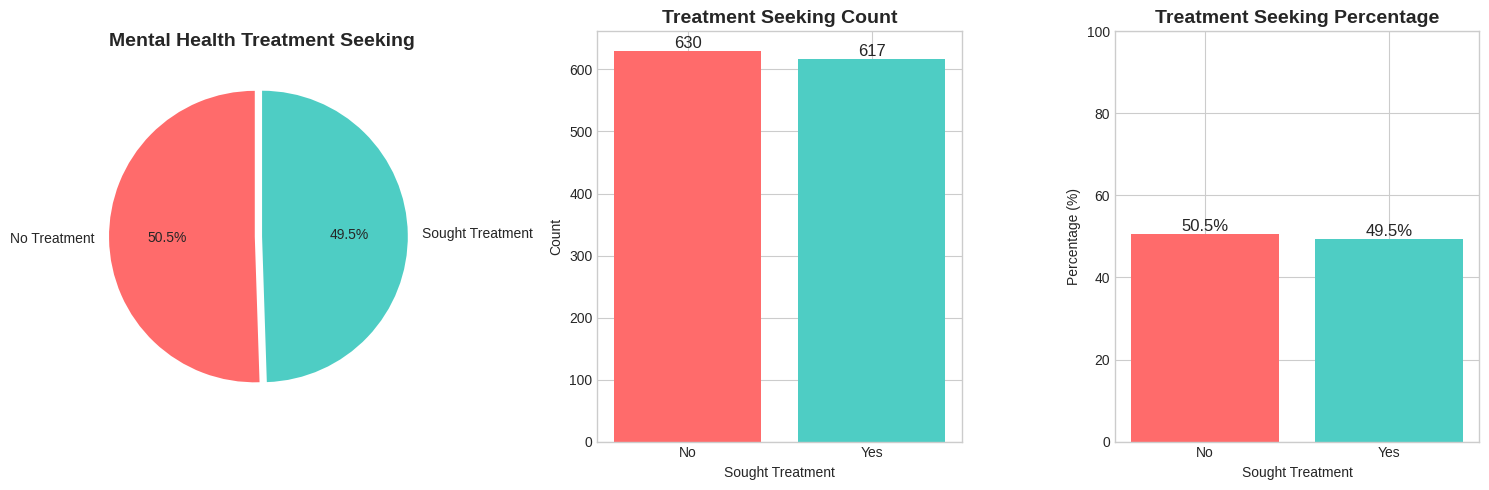

Sought Treatment: 630 respondents (50.5%)
No Treatment: 617 respondents (49.5%)

2. AGE DISTRIBUTION ANALYSIS


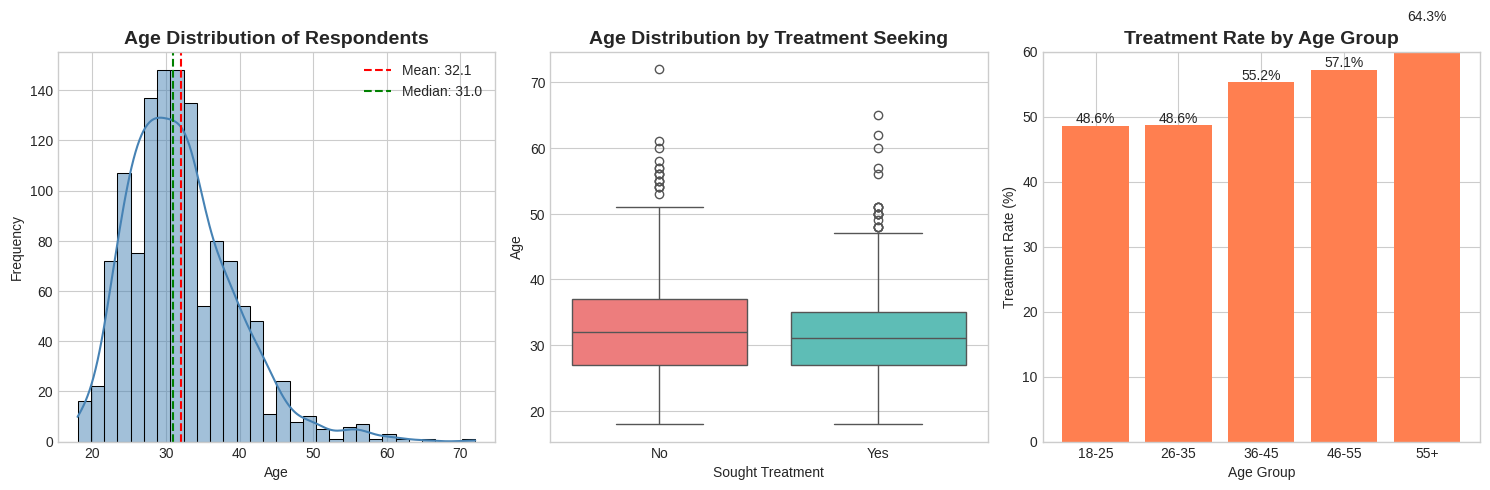

Mean age: 32.1 years
Median age: 31.0 years
Age range: 18 to 72 years

Treatment rate by age group:
age_group
18-25    48.6
26-35    48.6
36-45    55.2
46-55    57.1
55+      64.3
Name: treatment, dtype: float64

3. GENDER ANALYSIS


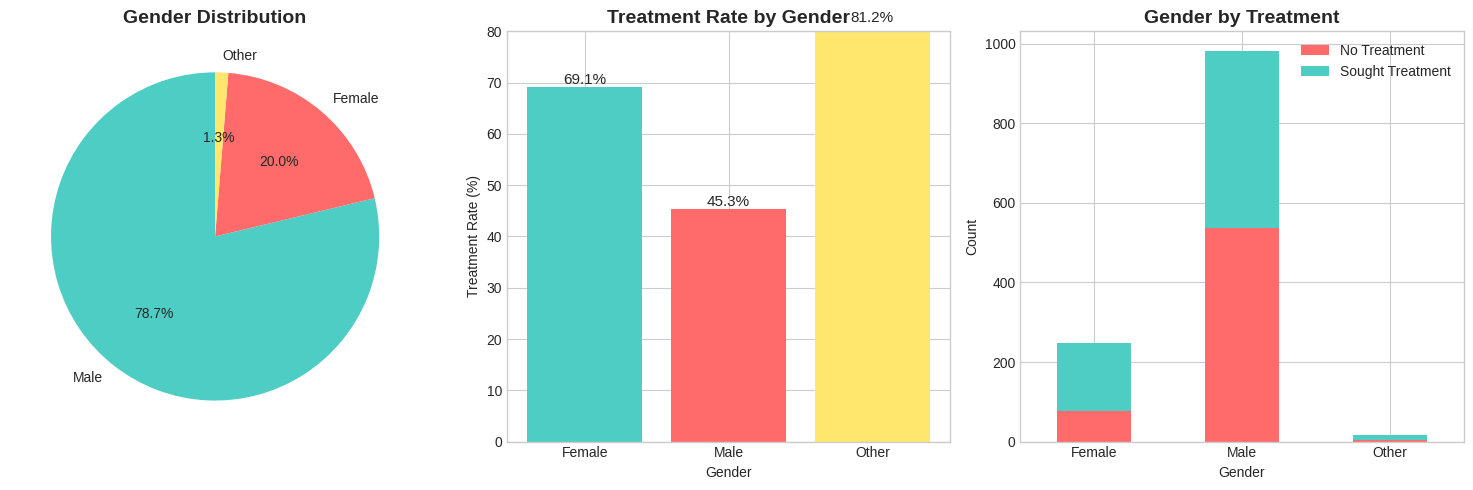

Treatment rate by gender:
  Female: 69.1%
  Male: 45.3%
  Other: 81.2%

4. FAMILY HISTORY IMPACT


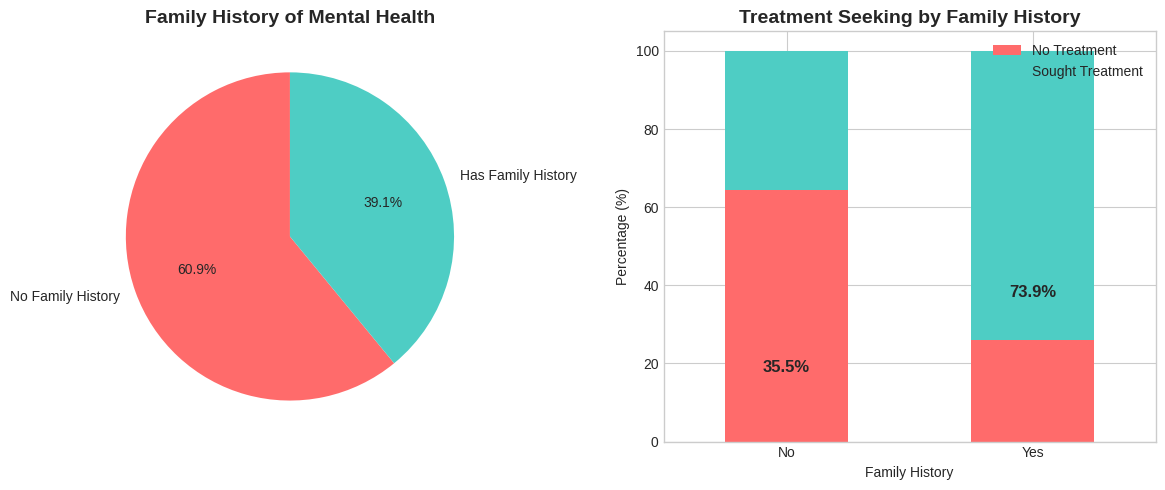

Treatment rate with family history: 73.9%
Treatment rate without family history: 35.5%
Difference: +38.4 percentage points

5. WORK INTERFERENCE ANALYSIS


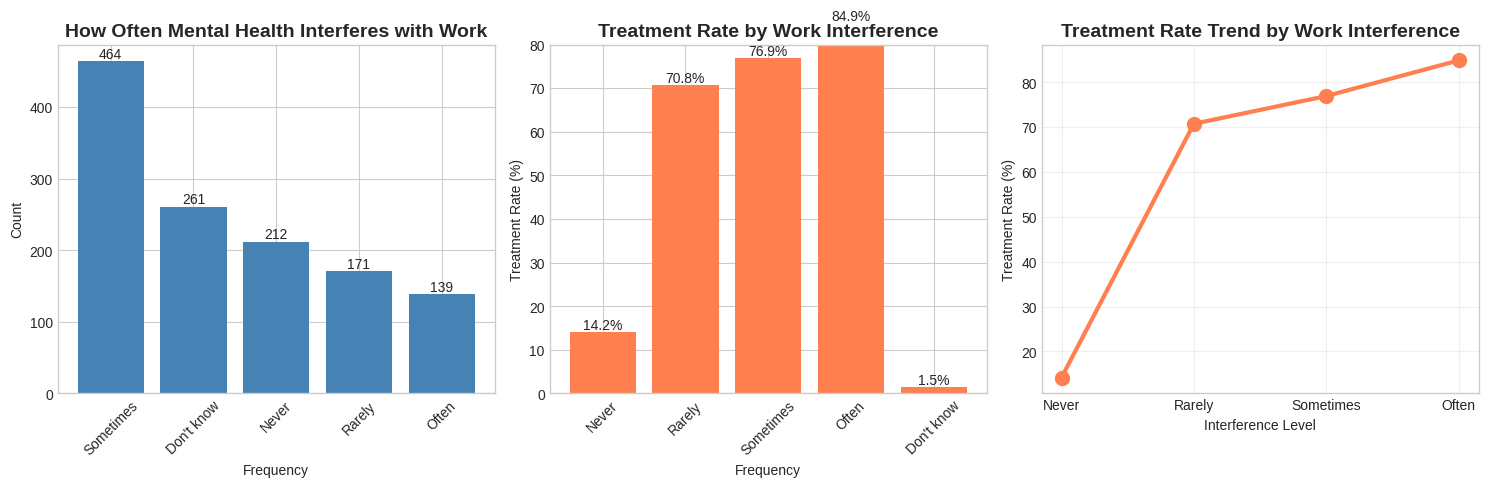

Treatment rate by work interference:
  Never: 14.2%
  Rarely: 70.8%
  Sometimes: 76.9%
  Often: 84.9%
  Don't know: 1.5%

6. COMPANY SIZE ANALYSIS


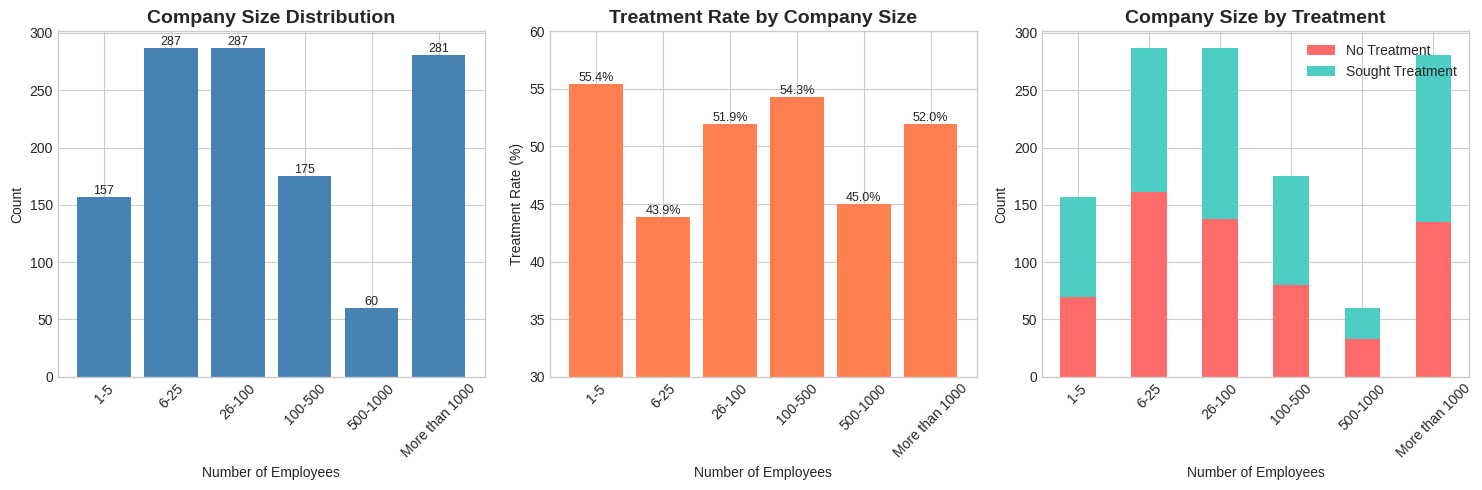

Treatment rate by company size:
  1-5: 55.4%
  6-25: 43.9%
  26-100: 51.9%
  100-500: 54.3%
  500-1000: 45.0%
  More than 1000: 52.0%

7. WORKPLACE BENEFITS IMPACT


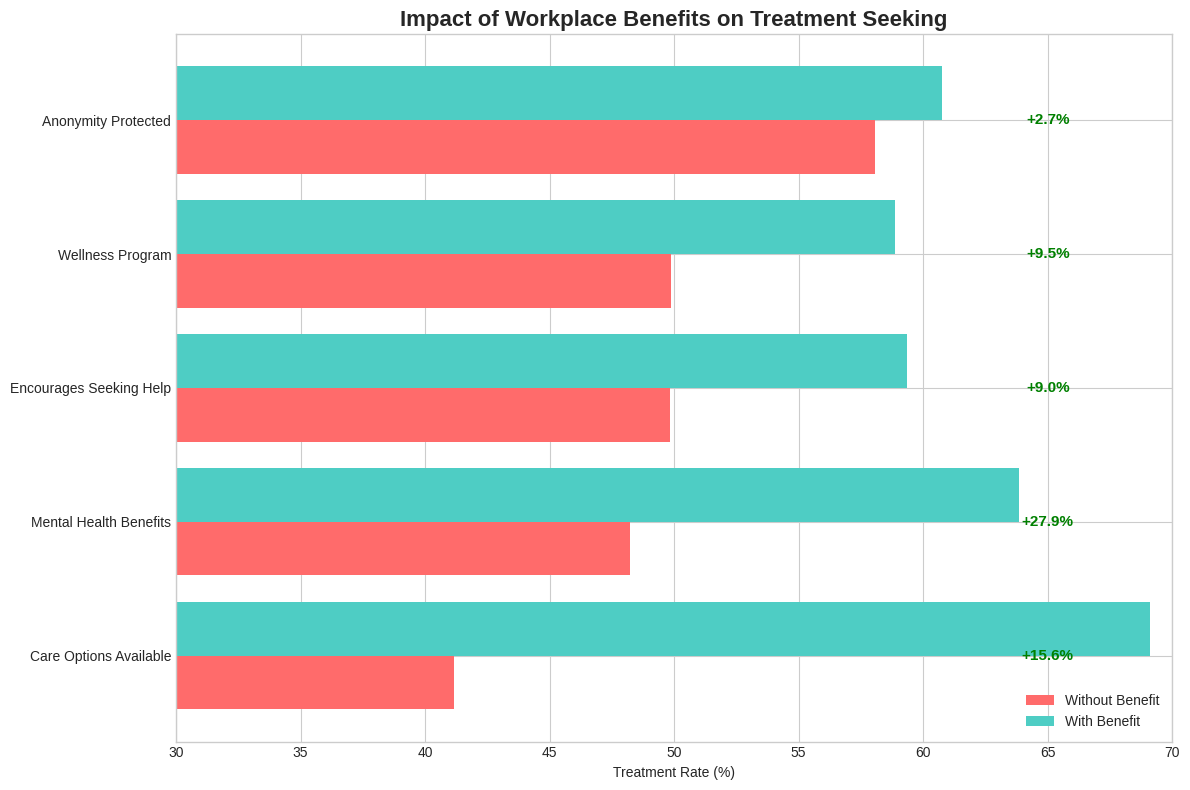

Impact of workplace benefits on treatment seeking:
                Benefit  With Benefit  Without Benefit  Difference
 Care Options Available          69.1             41.2        27.9
 Mental Health Benefits          63.8             48.2        15.6
Encourages Seeking Help          59.3             49.8         9.5
       Wellness Program          58.8             49.9         9.0
    Anonymity Protected          60.8             58.1         2.7

8. FEAR OF CONSEQUENCES


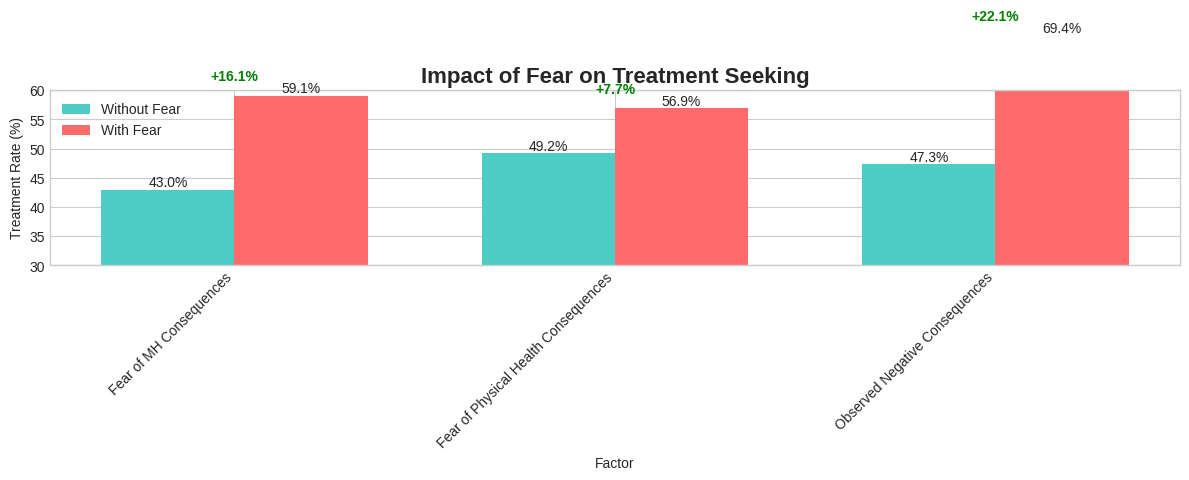

Impact of fear on treatment seeking:
                              Factor  With Fear/Observed  Without Fear/Observed  Difference
             Fear of MH Consequences                59.1                   43.0        16.1
Fear of Physical Health Consequences                56.9                   49.2         7.7
      Observed Negative Consequences                69.4                   47.3        22.1

9. CORRELATION ANALYSIS
Encoded family_history: [0. 1.]
Encoded remote_work: [0. 1.]
Encoded tech_company: [1. 0.]
Encoded self_employed: [0. 1.]
Encoded benefits: [1.  0.5 0. ]
Encoded care_options: [0.5 0.  1. ]
Encoded wellness_program: [0.  0.5 1. ]
Encoded seek_help: [1.  0.5 0. ]
Encoded anonymity: [1.  0.5 0. ]
Encoded mental_health_consequence: [0.  0.5 1. ]
Encoded phys_health_consequence: [0.  1.  0.5]
Encoded obs_consequence: [0. 1.]

Encoded treatment: [1 0]
Encoded Gender: [1 0 2]
Encoded work_interfere: [3.0, 1.0, 0.0, 2.0, 1.5]
Categories (5, float64): [0.0 < 1.0 < 2.0 < 3

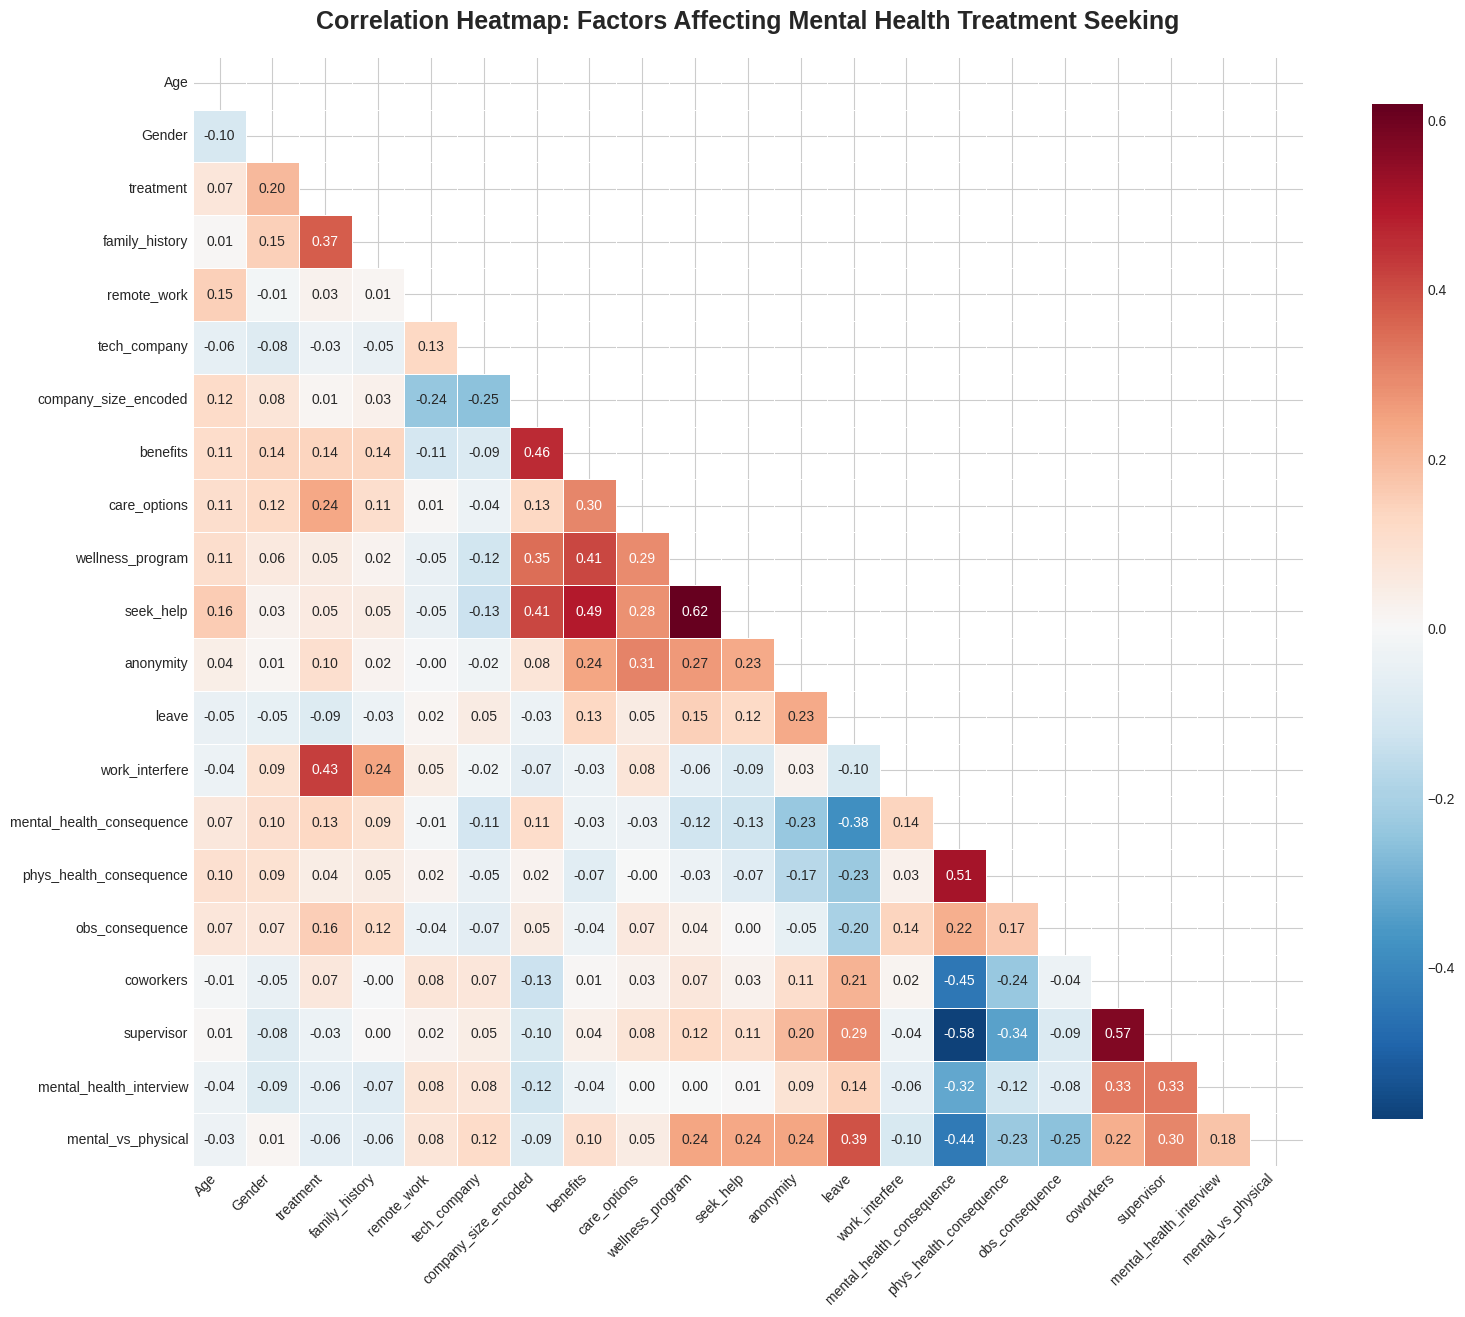


TOP CORRELATIONS WITH TREATMENT SEEKING
  Work Interference Level: 0.426 (Positive, Strong)
  Family History: 0.375 (Positive, Strong)
  Care Options Available: 0.237 (Positive, Moderate)
  Gender (F>M): 0.201 (Positive, Moderate)
  Observed Negative Consequences: 0.155 (Positive, Moderate)
  Mental Health Benefits: 0.140 (Positive, Weak)
  Fear of MH Consequences: 0.127 (Positive, Weak)
  Anonymity Protection: 0.100 (Positive, Weak)
  Age: 0.072 (Positive, Weak)
  Would Discuss with Coworkers: 0.069 (Positive, Weak)
  Encourages Seeking Help: 0.053 (Positive, Weak)
  Wellness Program: 0.050 (Positive, Weak)
  Fear of Physical Health Consequences: 0.045 (Positive, Weak)
  Remote Work: 0.027 (Positive, Weak)
  Company Size: 0.015 (Positive, Weak)
  Tech Company: -0.031 (Negative, Weak)
  Would Discuss with Supervisor: -0.034 (Negative, Weak)
  Would Discuss in Interview: -0.060 (Negative, Weak)
  Mental = Physical Health: -0.061 (Negative, Weak)
  Ease of Taking Leave: -0.086 (Negative

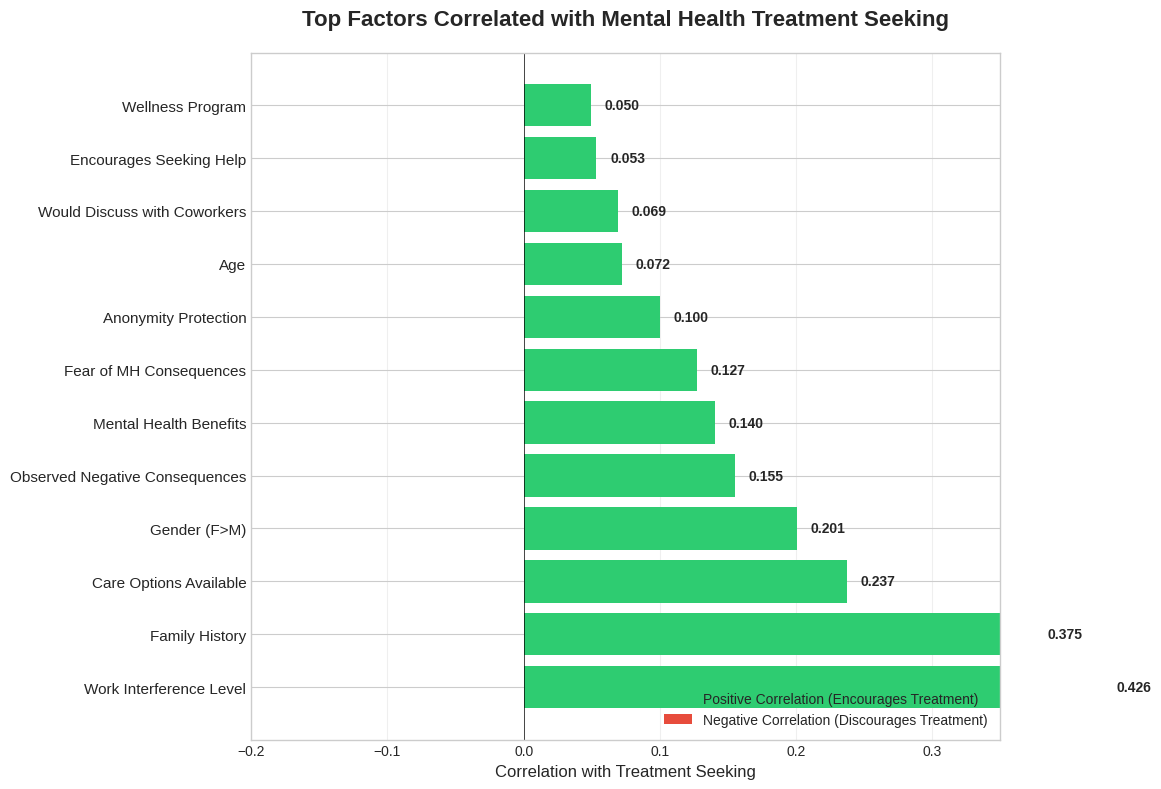


KEY CORRELATION FINDINGS

✅ STRONGEST POSITIVE CORRELATION:
   Work Interference Level (0.426)
   → This factor most strongly encourages treatment seeking

❌ STRONGEST NEGATIVE CORRELATION:
   Ease of Taking Leave (-0.086)
   → This factor most strongly discourages treatment seeking

📊 CORRELATION GROUPS:
   • Family/Personal: 0.375
   • Care Options Available: 0.237
   • Anonymity Protection: 0.100
   • Encourages Seeking Help: 0.053
   • Mental Health Benefits: 0.140
   • Mental = Physical Health: -0.061
   • Ease of Taking Leave: -0.086
   • Wellness Program: 0.050
   • Fear of MH Consequences: 0.127
   • Observed Negative Consequences: 0.155
   • Fear of Physical Health Consequences: 0.045


In [18]:
# ============================================
# SECTION 2.2: EXPLORATORY DATA ANALYSIS
# ============================================

# Set up the plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create a figure for the EDA summary
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ============================================
# 1. TREATMENT DISTRIBUTION (Target Variable)
# ============================================
print("\n" + "=" * 40)
print("1. TREATMENT SEEKING DISTRIBUTION")
print("=" * 40)

plt.figure(figsize=(15, 5))

# Pie chart
plt.subplot(1, 3, 1)
treatment_counts = df_clean['treatment'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
plt.pie(treatment_counts, labels=['No Treatment', 'Sought Treatment'],
        autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
plt.title('Mental Health Treatment Seeking', fontsize=14, fontweight='bold')

# Bar chart
plt.subplot(1, 3, 2)
bars = plt.bar(treatment_counts.index, treatment_counts.values, color=['#ff6b6b', '#4ecdc4'])
plt.title('Treatment Seeking Count', fontsize=14, fontweight='bold')
plt.xlabel('Sought Treatment')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

# Percentage bar
plt.subplot(1, 3, 3)
treatment_pct = df_clean['treatment'].value_counts(normalize=True) * 100
bars = plt.bar(treatment_pct.index, treatment_pct.values, color=['#ff6b6b', '#4ecdc4'])
plt.title('Treatment Seeking Percentage', fontsize=14, fontweight='bold')
plt.xlabel('Sought Treatment')
plt.ylabel('Percentage (%)')
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylim(0, 100)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Sought Treatment: {treatment_counts['Yes']} respondents ({treatment_counts['Yes']/len(df_clean)*100:.1f}%)")
print(f"No Treatment: {treatment_counts['No']} respondents ({treatment_counts['No']/len(df_clean)*100:.1f}%)")

# ============================================
# 2. AGE ANALYSIS
# ============================================
print("\n" + "=" * 40)
print("2. AGE DISTRIBUTION ANALYSIS")
print("=" * 40)

plt.figure(figsize=(15, 5))

# Age distribution
plt.subplot(1, 3, 1)
sns.histplot(data=df_clean, x='Age', bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.axvline(df_clean['Age'].mean(), color='red', linestyle='--',
            label=f'Mean: {df_clean["Age"].mean():.1f}')
plt.axvline(df_clean['Age'].median(), color='green', linestyle='--',
            label=f'Median: {df_clean["Age"].median():.1f}')
plt.legend()

# Age by treatment
plt.subplot(1, 3, 2)
sns.boxplot(x='treatment', y='Age', data=df_clean, palette=['#ff6b6b', '#4ecdc4'])
plt.title('Age Distribution by Treatment Seeking', fontsize=14, fontweight='bold')
plt.xlabel('Sought Treatment')
plt.ylabel('Age')
plt.xticks([0, 1], ['No', 'Yes'])

# Age groups
plt.subplot(1, 3, 3)
df_clean['age_group'] = pd.cut(df_clean['Age'], bins=[18, 25, 35, 45, 55, 100],
                                labels=['18-25', '26-35', '36-45', '46-55', '55+'])
age_group_treatment = df_clean.groupby('age_group')['treatment'].apply(lambda x: (x == 'Yes').mean()) * 100
bars = plt.bar(age_group_treatment.index, age_group_treatment.values, color='coral')
plt.title('Treatment Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Treatment Rate (%)')
plt.ylim(0, 60)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean age: {df_clean['Age'].mean():.1f} years")
print(f"Median age: {df_clean['Age'].median():.1f} years")
print(f"Age range: {df_clean['Age'].min()} to {df_clean['Age'].max()} years")
print("\nTreatment rate by age group:")
print(age_group_treatment.round(1))

# ============================================
# 3. GENDER ANALYSIS
# ============================================
print("\n" + "=" * 40)
print("3. GENDER ANALYSIS")
print("=" * 40)

plt.figure(figsize=(15, 5))

# Gender distribution
plt.subplot(1, 3, 1)
gender_counts = df_clean['Gender'].value_counts()
colors = ['#4ecdc4', '#ff6b6b', '#ffe66d']
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Gender Distribution', fontsize=14, fontweight='bold')

# Treatment by gender
plt.subplot(1, 3, 2)
gender_treatment = df_clean.groupby('Gender')['treatment'].apply(lambda x: (x == 'Yes').mean()) * 100
bars = plt.bar(gender_treatment.index, gender_treatment.values, color=['#4ecdc4', '#ff6b6b', '#ffe66d'])
plt.title('Treatment Rate by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Treatment Rate (%)')
plt.ylim(0, 80)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

# Gender count by treatment
plt.subplot(1, 3, 3)
gender_treatment_counts = pd.crosstab(df_clean['Gender'], df_clean['treatment'])
gender_treatment_counts.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4ecdc4'], ax=plt.gca())
plt.title('Gender by Treatment', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['No Treatment', 'Sought Treatment'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("Treatment rate by gender:")
for gender, rate in gender_treatment.items():
    print(f"  {gender}: {rate:.1f}%")

# ============================================
# 4. FAMILY HISTORY IMPACT
# ============================================
print("\n" + "=" * 40)
print("4. FAMILY HISTORY IMPACT")
print("=" * 40)

plt.figure(figsize=(12, 5))

# Family history distribution
plt.subplot(1, 2, 1)
family_counts = df_clean['family_history'].value_counts()
plt.pie(family_counts, labels=['No Family History', 'Has Family History'],
        autopct='%1.1f%%', colors=['#ff6b6b', '#4ecdc4'], startangle=90)
plt.title('Family History of Mental Health', fontsize=14, fontweight='bold')

# Treatment by family history
plt.subplot(1, 2, 2)
family_treatment = pd.crosstab(df_clean['family_history'], df_clean['treatment'], normalize='index') * 100
family_treatment.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4ecdc4'], ax=plt.gca())
plt.title('Treatment Seeking by Family History', fontsize=14, fontweight='bold')
plt.xlabel('Family History')
plt.ylabel('Percentage (%)')
plt.legend(['No Treatment', 'Sought Treatment'])
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

# Add percentages
for i, (idx, row) in enumerate(family_treatment.iterrows()):
    plt.text(i, row['Yes']/2, f'{row["Yes"]:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Treatment rate with family history: {:.1f}%".format(
    df_clean[df_clean['family_history'] == 'Yes']['treatment'].value_counts(normalize=True)['Yes'] * 100))
print("Treatment rate without family history: {:.1f}%".format(
    df_clean[df_clean['family_history'] == 'No']['treatment'].value_counts(normalize=True)['Yes'] * 100))
print(f"Difference: +{family_treatment.loc['Yes', 'Yes'] - family_treatment.loc['No', 'Yes']:.1f} percentage points")

# ============================================
# 5. WORK INTERFERENCE ANALYSIS
# ============================================
print("\n" + "=" * 40)
print("5. WORK INTERFERENCE ANALYSIS")
print("=" * 40)

plt.figure(figsize=(15, 5))

# Work interference distribution
plt.subplot(1, 3, 1)
work_counts = df_clean['work_interfere'].value_counts()
bars = plt.bar(work_counts.index, work_counts.values, color='steelblue')
plt.title('How Often Mental Health Interferes with Work', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Treatment rate by work interference
plt.subplot(1, 3, 2)
work_treatment = df_clean.groupby('work_interfere')['treatment'].apply(lambda x: (x == 'Yes').mean()) * 100
bars = plt.bar(work_treatment.index, work_treatment.values, color='coral')
plt.title('Treatment Rate by Work Interference', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Treatment Rate (%)')
plt.ylim(0, 80)
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Line plot showing trend
plt.subplot(1, 3, 3)
work_order = ['Never', 'Rarely', 'Sometimes', 'Often']
work_trend = [work_treatment.get(x, 0) for x in work_order]
plt.plot(work_order, work_trend, marker='o', linewidth=3, markersize=10, color='coral')
plt.title('Treatment Rate Trend by Work Interference', fontsize=14, fontweight='bold')
plt.xlabel('Interference Level')
plt.ylabel('Treatment Rate (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Treatment rate by work interference:")
for level, rate in work_treatment.items():
    print(f"  {level}: {rate:.1f}%")

# ============================================
# 6. COMPANY SIZE ANALYSIS
# ============================================
print("\n" + "=" * 40)
print("6. COMPANY SIZE ANALYSIS")
print("=" * 40)

plt.figure(figsize=(15, 5))

# Company size distribution
plt.subplot(1, 3, 1)
size_counts = df_clean['no_employees'].value_counts().sort_index()
bars = plt.bar(range(len(size_counts)), size_counts.values, color='steelblue')
plt.title('Company Size Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(range(len(size_counts)), size_counts.index, rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Treatment rate by company size
plt.subplot(1, 3, 2)
size_treatment = df_clean.groupby('no_employees')['treatment'].apply(lambda x: (x == 'Yes').mean()) * 100
size_treatment = size_treatment.sort_index()
bars = plt.bar(range(len(size_treatment)), size_treatment.values, color='coral')
plt.title('Treatment Rate by Company Size', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employees')
plt.ylabel('Treatment Rate (%)')
plt.xticks(range(len(size_treatment)), size_treatment.index, rotation=45)
plt.ylim(30, 60)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Count by company size and treatment
plt.subplot(1, 3, 3)
size_treatment_counts = pd.crosstab(df_clean['no_employees'], df_clean['treatment'])
size_treatment_counts.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4ecdc4'], ax=plt.gca())
plt.title('Company Size by Treatment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.legend(['No Treatment', 'Sought Treatment'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Treatment rate by company size:")
for size, rate in size_treatment.items():
    print(f"  {size}: {rate:.1f}%")

# ============================================
# 7. WORKPLACE BENEFITS IMPACT
# ============================================
print("\n" + "=" * 40)
print("7. WORKPLACE BENEFITS IMPACT")
print("=" * 40)

benefit_vars = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
benefit_labels = {
    'benefits': 'Mental Health Benefits',
    'care_options': 'Care Options Available',
    'wellness_program': 'Wellness Program',
    'seek_help': 'Encourages Seeking Help',
    'anonymity': 'Anonymity Protected'
}

benefit_impact = []
for var in benefit_vars:
    yes_rate = df_clean[df_clean[var] == 'Yes']['treatment'].apply(lambda x: x == 'Yes').mean() * 100
    no_rate = df_clean[df_clean[var] == 'No']['treatment'].apply(lambda x: x == 'Yes').mean() * 100
    benefit_impact.append({
        'Benefit': benefit_labels[var],
        'With Benefit': yes_rate,
        'Without Benefit': no_rate,
        'Difference': yes_rate - no_rate
    })

benefit_df = pd.DataFrame(benefit_impact).sort_values('Difference', ascending=False)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(benefit_df))
plt.barh(y_pos - 0.2, benefit_df['Without Benefit'], height=0.4, label='Without Benefit', color='#ff6b6b')
plt.barh(y_pos + 0.2, benefit_df['With Benefit'], height=0.4, label='With Benefit', color='#4ecdc4')
plt.yticks(y_pos, benefit_df['Benefit'])
plt.xlabel('Treatment Rate (%)')
plt.title('Impact of Workplace Benefits on Treatment Seeking', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.xlim(30, 70)

# Add difference annotations
for i, row in benefit_df.iterrows():
    plt.text(65, i, f'+{row["Difference"]:.1f}%', ha='center', va='center',
             fontweight='bold', color='green', fontsize=11)

plt.tight_layout()
plt.show()

print("Impact of workplace benefits on treatment seeking:")
print(benefit_df.round(1).to_string(index=False))

# ============================================
# 8. FEAR OF CONSEQUENCES
# ============================================
print("\n" + "=" * 40)
print("8. FEAR OF CONSEQUENCES")
print("=" * 40)

fear_vars = ['mental_health_consequence', 'phys_health_consequence', 'obs_consequence']
fear_labels = {
    'mental_health_consequence': 'Fear of MH Consequences',
    'phys_health_consequence': 'Fear of Physical Health Consequences',
    'obs_consequence': 'Observed Negative Consequences'
}

fear_impact = []
for var in fear_vars:
    yes_rate = df_clean[df_clean[var] == 'Yes']['treatment'].apply(lambda x: x == 'Yes').mean() * 100
    no_rate = df_clean[df_clean[var] == 'No']['treatment'].apply(lambda x: x == 'Yes').mean() * 100
    fear_impact.append({
        'Factor': fear_labels[var],
        'With Fear/Observed': yes_rate,
        'Without Fear/Observed': no_rate,
        'Difference': yes_rate - no_rate
    })

fear_df = pd.DataFrame(fear_impact)

plt.figure(figsize=(12, 6))
x_pos = np.arange(len(fear_df))
width = 0.35

bars1 = plt.bar(x_pos - width/2, fear_df['Without Fear/Observed'], width, label='Without Fear', color='#4ecdc4')
bars2 = plt.bar(x_pos + width/2, fear_df['With Fear/Observed'], width, label='With Fear', color='#ff6b6b')

plt.xlabel('Factor')
plt.ylabel('Treatment Rate (%)')
plt.title('Impact of Fear on Treatment Seeking', fontsize=16, fontweight='bold')
plt.xticks(x_pos, fear_df['Factor'], rotation=45, ha='right')
plt.legend()
plt.ylim(30, 60)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Add difference annotations
for i, row in fear_df.iterrows():
    diff = row['Difference']
    color = 'red' if diff < 0 else 'green'
    plt.text(i, max(row['With Fear/Observed'], row['Without Fear/Observed']) + 2,
             f'{diff:+.1f}%', ha='center', va='bottom', fontweight='bold', color=color)

plt.tight_layout()
plt.show()

print("Impact of fear on treatment seeking:")
print(fear_df.round(1).to_string(index=False))


# ============================================
# 9. CORRELATION ANALYSIS (COMPLETELY FIXED)
# ============================================
print("\n" + "=" * 40)
print("9. CORRELATION ANALYSIS")
print("=" * 40)

# Create a fresh copy for correlation analysis
df_corr = df_clean.copy()

# ============================================
# Step 1: Encode ALL categorical columns properly
# ============================================

# Function to safely encode values
def safe_encode(value, mapping):
    """Safely map values, defaulting to 0.5 for unknown"""
    if pd.isna(value):
        return np.nan
    value_str = str(value).strip()
    return mapping.get(value_str, 0.5)  # Default to 0.5 for unknown

# 1. Encode binary Yes/No columns (including 'Not sure' and 'Don\'t know')
binary_mapping = {
    'Yes': 1.0,
    'No': 0.0,
    'Don\'t know': 0.5,
    'Not sure': 0.5,
    'Maybe': 0.5
}

binary_cols = ['family_history', 'remote_work', 'tech_company', 'self_employed',
               'benefits', 'care_options', 'wellness_program', 'seek_help',
               'anonymity', 'mental_health_consequence', 'phys_health_consequence',
               'obs_consequence']

for col in binary_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].apply(lambda x: safe_encode(x, binary_mapping))
        print(f"Encoded {col}: {df_corr[col].unique()}")

# 2. Encode treatment (target variable)
df_corr['treatment'] = df_corr['treatment'].map({'Yes': 1, 'No': 0})
print(f"\nEncoded treatment: {df_corr['treatment'].unique()}")

# 3. Encode gender
gender_mapping = {'Male': 0, 'Female': 1, 'Other': 2}
df_corr['Gender'] = df_corr['Gender'].map(gender_mapping)
print(f"Encoded Gender: {df_corr['Gender'].unique()}")

# 4. Encode work_interfere (ordinal)
work_mapping = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Don\'t know': 1.5
}
df_corr['work_interfere'] = df_corr['work_interfere'].apply(lambda x: safe_encode(x, work_mapping))
print(f"Encoded work_interfere: {df_corr['work_interfere'].unique()}")

# 5. Encode leave (ordinal)
leave_mapping = {
    'Very difficult': 0,
    'Somewhat difficult': 1,
    'Don\'t know': 2,
    'Somewhat easy': 3,
    'Very easy': 4
}
df_corr['leave'] = df_corr['leave'].apply(lambda x: safe_encode(x, leave_mapping))
print(f"Encoded leave: {df_corr['leave'].unique()}")

# 6. Encode coworkers and supervisor
coworker_mapping = {
    'No': 0,
    'Some of them': 1,
    'Yes': 2
}
df_corr['coworkers'] = df_corr['coworkers'].apply(lambda x: safe_encode(x, coworker_mapping))
df_corr['supervisor'] = df_corr['supervisor'].apply(lambda x: safe_encode(x, coworker_mapping))
print(f"Encoded coworkers: {df_corr['coworkers'].unique()}")
print(f"Encoded supervisor: {df_corr['supervisor'].unique()}")

# 7. Encode mental_health_interview and phys_health_interview
interview_mapping = {
    'No': 0,
    'Maybe': 0.5,
    'Yes': 1
}
df_corr['mental_health_interview'] = df_corr['mental_health_interview'].apply(lambda x: safe_encode(x, interview_mapping))
df_corr['phys_health_interview'] = df_corr['phys_health_interview'].apply(lambda x: safe_encode(x, interview_mapping))
print(f"Encoded mental_health_interview: {df_corr['mental_health_interview'].unique()}")
print(f"Encoded phys_health_interview: {df_corr['phys_health_interview'].unique()}")

# 8. Encode mental_vs_physical
mvp_mapping = {
    'No': 0,
    'Don\'t know': 0.5,
    'Yes': 1
}
df_corr['mental_vs_physical'] = df_corr['mental_vs_physical'].apply(lambda x: safe_encode(x, mvp_mapping))
print(f"Encoded mental_vs_physical: {df_corr['mental_vs_physical'].unique()}")

# 9. Encode no_employees (company size) - ordinal
size_mapping = {
    '1-5': 1,
    '6-25': 2,
    '26-100': 3,
    '100-500': 4,
    '500-1000': 5,
    'More than 1000': 6
}
df_corr['company_size_encoded'] = df_corr['no_employees'].astype(str).map(size_mapping)
print(f"Encoded company size: {df_corr['company_size_encoded'].unique()}")

# ============================================
# Step 2: Select numeric columns for correlation
# ============================================

# Get all numeric columns
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nAll numeric columns: {numeric_cols}")

# Select key columns for correlation (focus on most important ones)
key_cols = [
    'Age', 'Gender', 'treatment', 'family_history', 'remote_work',
    'tech_company', 'company_size_encoded', 'benefits', 'care_options',
    'wellness_program', 'seek_help', 'anonymity', 'leave', 'work_interfere',
    'mental_health_consequence', 'phys_health_consequence', 'obs_consequence',
    'coworkers', 'supervisor', 'mental_health_interview', 'mental_vs_physical'
]

# Filter to available columns
available_key_cols = [col for col in key_cols if col in df_corr.columns]
print(f"\nKey columns for correlation: {available_key_cols}")

# ============================================
# Step 3: Calculate correlation matrix
# ============================================

corr_matrix = df_corr[available_key_cols].corr()

# ============================================
# Step 4: Create heatmap
# ============================================

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Factors Affecting Mental Health Treatment Seeking',
          fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================
# Step 5: Get correlations with treatment
# ============================================

treatment_corr = corr_matrix['treatment'].sort_values(ascending=False)
print("\n" + "=" * 60)
print("TOP CORRELATIONS WITH TREATMENT SEEKING")
print("=" * 60)

# Function to clean variable names for display
def clean_var_name(var_name):
    clean_names = {
        'family_history': 'Family History',
        'care_options': 'Care Options Available',
        'anonymity': 'Anonymity Protection',
        'seek_help': 'Encourages Seeking Help',
        'mental_health_interview': 'Would Discuss in Interview',
        'benefits': 'Mental Health Benefits',
        'work_interfere': 'Work Interference Level',
        'supervisor': 'Would Discuss with Supervisor',
        'coworkers': 'Would Discuss with Coworkers',
        'mental_vs_physical': 'Mental = Physical Health',
        'leave': 'Ease of Taking Leave',
        'obs_consequence': 'Observed Negative Consequences',
        'mental_health_consequence': 'Fear of MH Consequences',
        'phys_health_consequence': 'Fear of Physical Health Consequences',
        'remote_work': 'Remote Work',
        'tech_company': 'Tech Company',
        'company_size_encoded': 'Company Size',
        'wellness_program': 'Wellness Program',
        'Gender': 'Gender (F>M)',
        'Age': 'Age'
    }
    return clean_names.get(var_name, var_name.replace('_', ' ').title())

# Display all correlations
for var, corr in treatment_corr.items():
    if var != 'treatment':
        strength = "Strong" if abs(corr) > 0.3 else "Moderate" if abs(corr) > 0.15 else "Weak"
        direction = "Positive" if corr > 0 else "Negative"
        print(f"  {clean_var_name(var)}: {corr:.3f} ({direction}, {strength})")

# ============================================
# Step 6: Create bar plot of top correlations
# ============================================

plt.figure(figsize=(12, 8))
top_corr = treatment_corr.drop('treatment').head(12)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_corr.values]
bars = plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), [clean_var_name(var) for var in top_corr.index], fontsize=11)
plt.xlabel('Correlation with Treatment Seeking', fontsize=12)
plt.title('Top Factors Correlated with Mental Health Treatment Seeking',
          fontsize=16, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.xlim(-0.2, 0.35)

# Add value labels
for i, (var, v) in enumerate(top_corr.items()):
    plt.text(v + (0.01 if v > 0 else -0.03), i, f'{v:.3f}',
             va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Positive Correlation (Encourages Treatment)'),
    Patch(facecolor='#e74c3c', label='Negative Correlation (Discourages Treatment)')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# ============================================
# Step 7: Summary of key findings
# ============================================

print("\n" + "=" * 60)
print("KEY CORRELATION FINDINGS")
print("=" * 60)

# Find strongest positive (excluding treatment itself)
positive_corr = treatment_corr[treatment_corr > 0].drop('treatment')
if not positive_corr.empty:
    top_positive = positive_corr.idxmax()
    print(f"\n STRONGEST POSITIVE CORRELATION:")
    print(f"   {clean_var_name(top_positive)} ({positive_corr.max():.3f})")
    print(f"   → This factor most strongly encourages treatment seeking")

# Find strongest negative
negative_corr = treatment_corr[treatment_corr < 0]
if not negative_corr.empty:
    top_negative = negative_corr.idxmin()
    print(f"\n STRONGEST NEGATIVE CORRELATION:")
    print(f"   {clean_var_name(top_negative)} ({negative_corr.min():.3f})")
    print(f"   → This factor most strongly discourages treatment seeking")

# Group findings
print("\n CORRELATION GROUPS:")

family = [c for c in treatment_corr.index if 'family' in c]
if family:
    print(f"   • Family/Personal: {treatment_corr[family[0]]:.3f}")

workplace_positive = ['care_options', 'anonymity', 'seek_help', 'benefits',
                      'mental_vs_physical', 'leave', 'wellness_program']
for wp in workplace_positive:
    if wp in treatment_corr.index:
        print(f"   • {clean_var_name(wp)}: {treatment_corr[wp]:.3f}")

fear_vars = ['mental_health_consequence', 'obs_consequence', 'phys_health_consequence']
for fear in fear_vars:
    if fear in treatment_corr.index:
        print(f"   • {clean_var_name(fear)}: {treatment_corr[fear]:.3f}")




# Machine Learning / AI Methods


SECTION 3: ML/AI METHODS

Step 1: Feature Preparation
Number of features: 18
Features: ['Age', 'Gender', 'family_history', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'work_interfere', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'obs_consequence']

Step 2: Encoding Categorical Variables
Encoded family_history: [0 1]
Encoded remote_work: [0 1]
Encoded tech_company: [1 0]
Encoded Gender: [1 0 2]
Encoded benefits: [1.  0.5 0. ]
Encoded care_options: [0.5 0.  1. ]
Encoded wellness_program: [0.  0.5 1. ]
Encoded seek_help: [1.  0.5 0. ]
Encoded anonymity: [1.  0.5 0. ]
Encoded leave: [3. 2. 1. 0. 4.]
Encoded work_interfere: [3.  1.  0.  2.  1.5]
Encoded mental_health_consequence: [0.  0.5 1. ]
Encoded phys_health_consequence: [0.  1.  0.5]
Encoded obs_consequence: [0. 1.]
Encoded coworkers: [1. 0. 2.]
Encoded supervisor: [2. 0. 1.]
Encoded mental_health_in

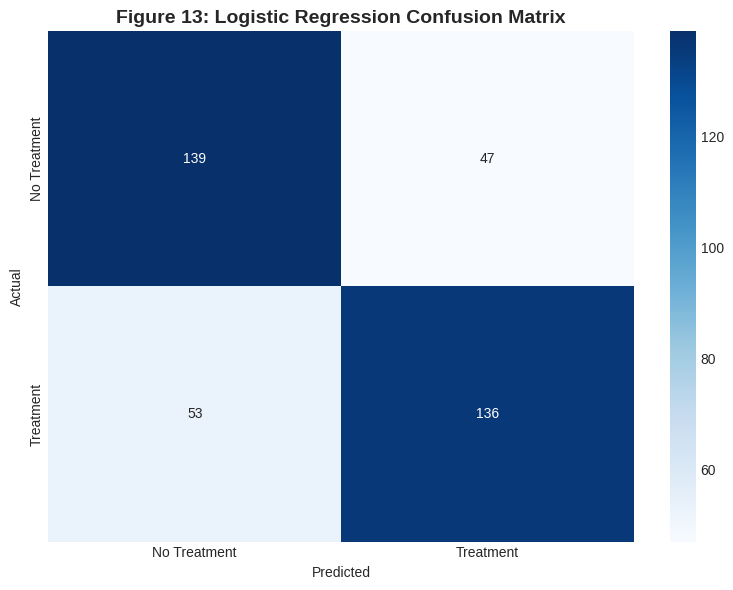


3.2 RANDOM FOREST
Accuracy: 0.8107
Precision: 0.7892
Recall: 0.8519
F1-Score: 0.8193
ROC-AUC: 0.8819


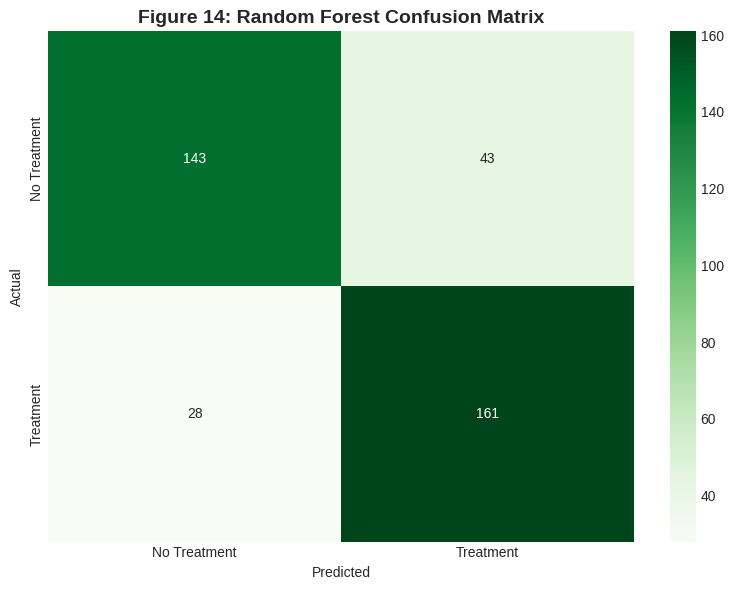

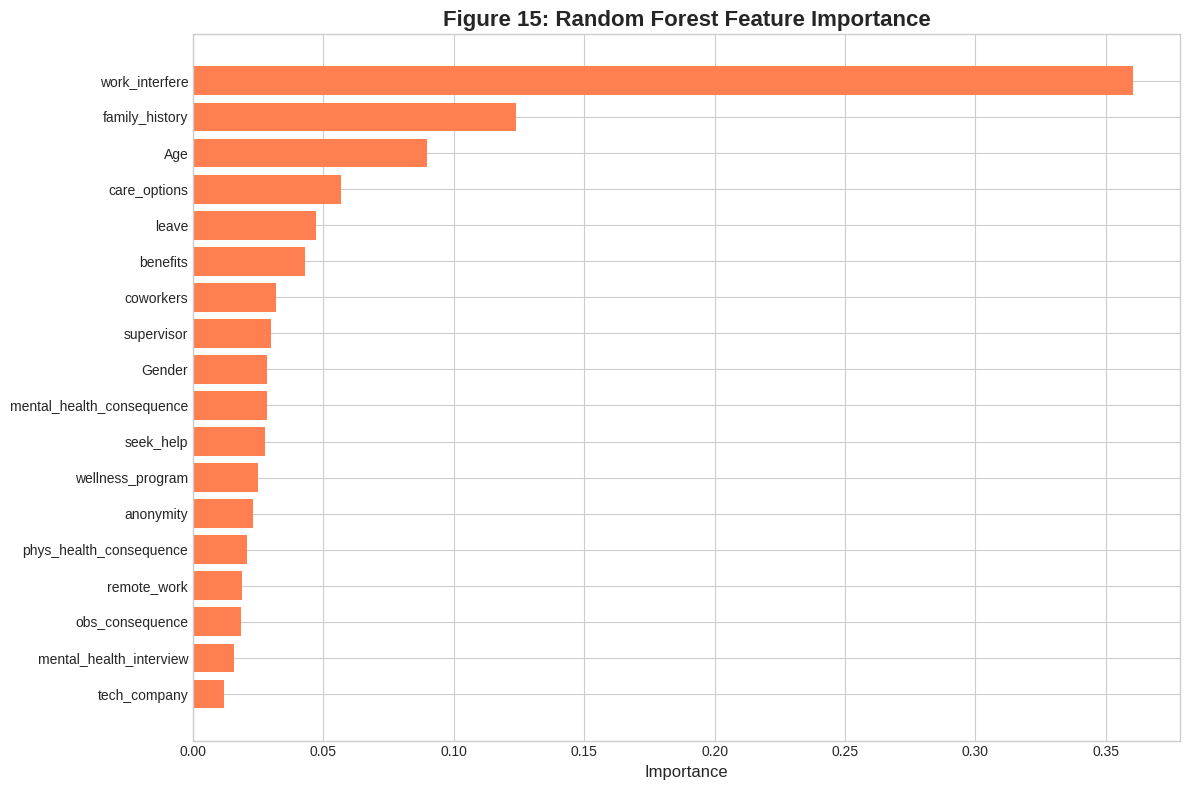


Top 10 Most Important Features:
                  Feature  Importance
           work_interfere    0.360465
           family_history    0.123862
                      Age    0.089697
             care_options    0.056889
                    leave    0.047296
                 benefits    0.042996
                coworkers    0.031607
               supervisor    0.029785
                   Gender    0.028491
mental_health_consequence    0.028259

3.3 GRADIENT BOOSTING
Accuracy: 0.7920
Precision: 0.7846
Recall: 0.8095
F1-Score: 0.7969
ROC-AUC: 0.8752


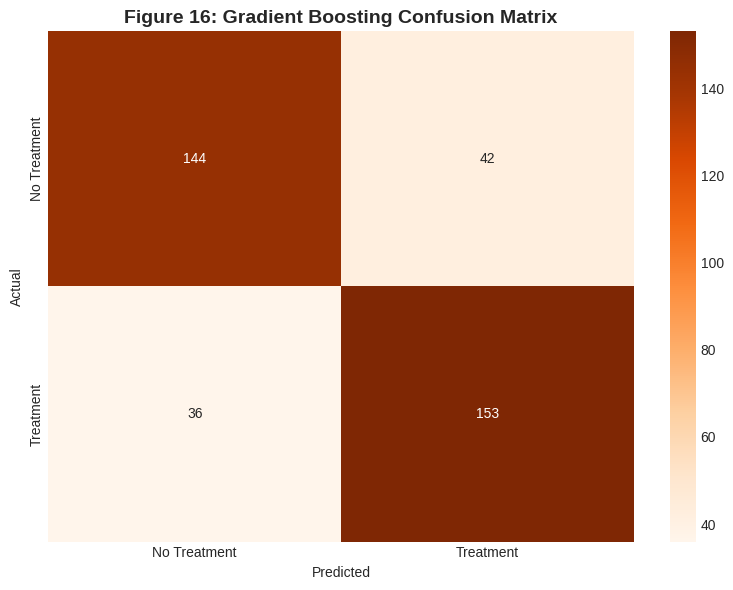


3.4 MODEL COMPARISON

Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7333     0.7432  0.7196    0.7312   0.8414
      Random Forest    0.8107     0.7892  0.8519    0.8193   0.8819
  Gradient Boosting    0.7920     0.7846  0.8095    0.7969   0.8752


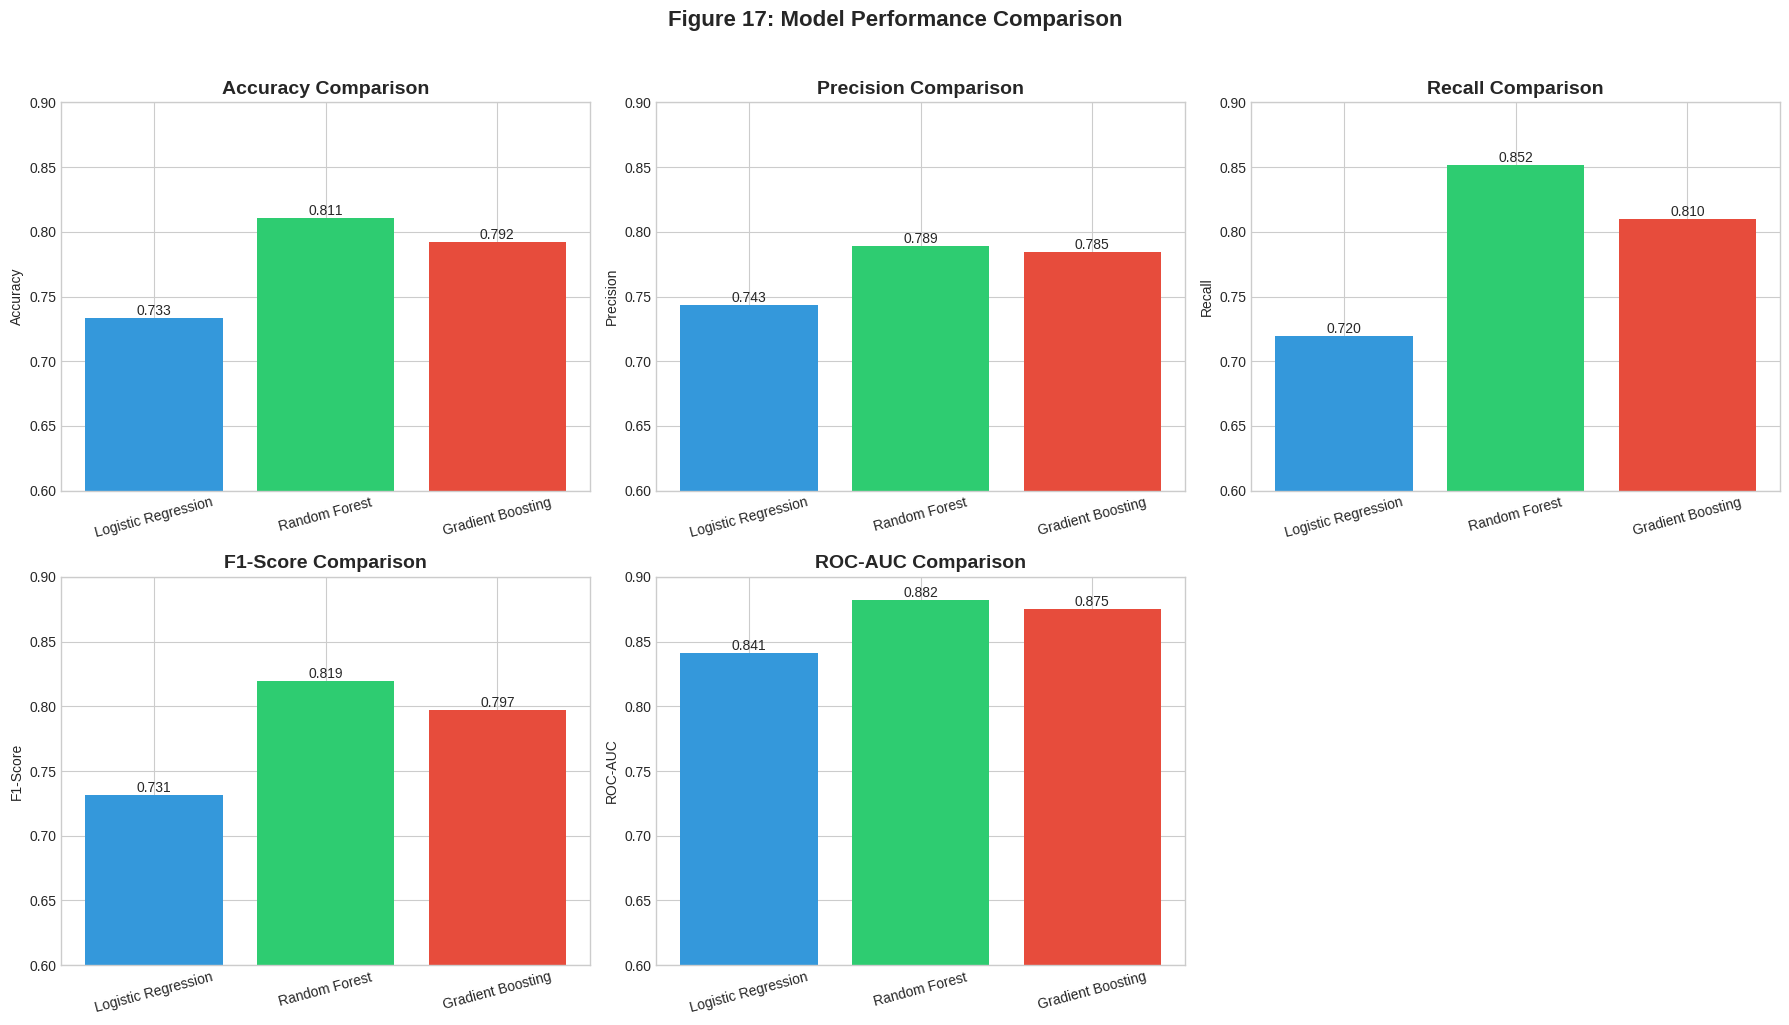

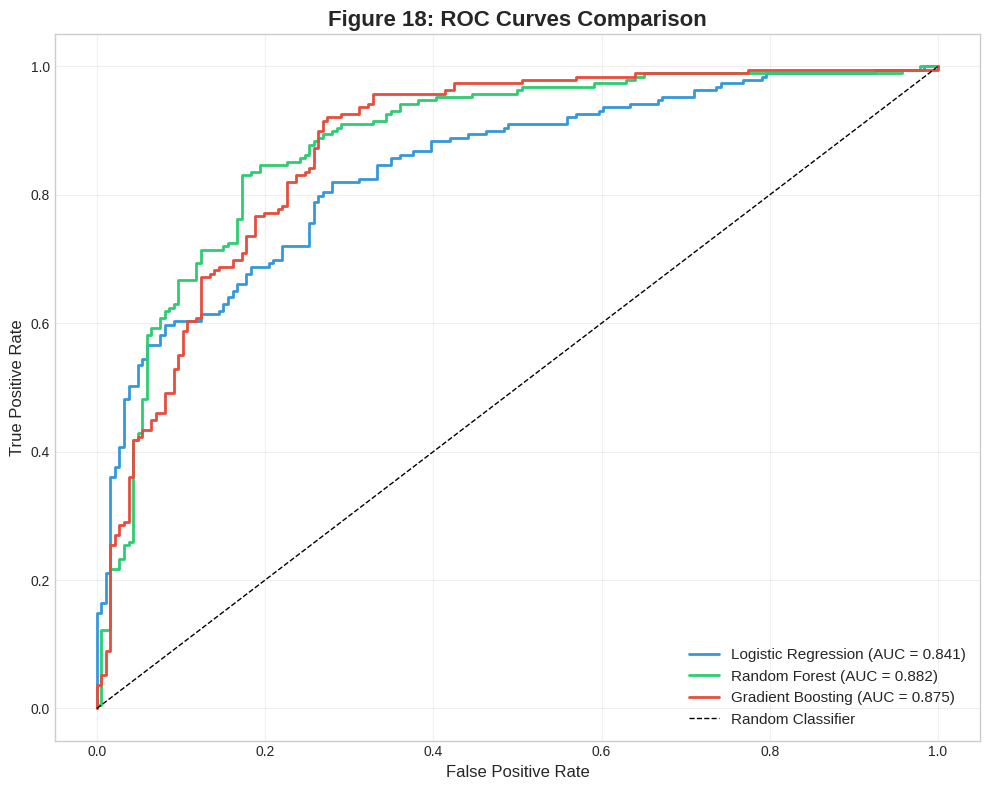

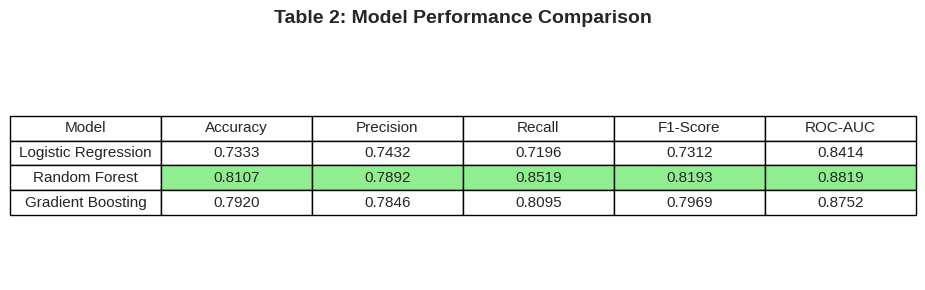


✅ BEST PERFORMER: Random Forest
   F1-Score: 0.8193
   ROC-AUC: 0.8819
   Accuracy: 0.8107


In [25]:
# ============================================
# SECTION 3: ML/AI METHODS (COMPLETELY FIXED WITH VISUALIZATIONS)
# ============================================
print("\n" + "=" * 60)
print("SECTION 3: ML/AI METHODS")
print("=" * 60)

# ============================================
# Step 1: Prepare features for modeling
# ============================================
print("\n" + "=" * 40)
print("Step 1: Feature Preparation")
print("=" * 40)

# Define feature columns (excluding target)
feature_cols = ['Age', 'Gender', 'family_history', 'remote_work', 'tech_company',
                'benefits', 'care_options', 'wellness_program', 'seek_help',
                'anonymity', 'leave', 'work_interfere', 'mental_health_consequence',
                'phys_health_consequence', 'coworkers', 'supervisor',
                'mental_health_interview', 'obs_consequence']

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Create a copy for modeling
df_model = df_clean.copy()

# ============================================
# Step 2: Encode categorical variables FIRST (before numeric conversion)
# ============================================
print("\n" + "=" * 40)
print("Step 2: Encoding Categorical Variables")
print("=" * 40)

# Dictionary to store mappings
encodings = {}

# 1. Encode binary Yes/No columns
binary_cols = ['family_history', 'remote_work', 'tech_company']
binary_mapping = {'Yes': 1, 'No': 0}

for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(binary_mapping)
        print(f"Encoded {col}: {df_model[col].unique()}")

# 2. Encode Gender
gender_mapping = {'Male': 0, 'Female': 1, 'Other': 2}
df_model['Gender'] = df_model['Gender'].map(gender_mapping)
print(f"Encoded Gender: {df_model['Gender'].unique()}")

# 3. Encode benefits, care_options, etc. (with Don't know)
benefit_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
benefit_mapping = {'Yes': 1, 'No': 0, 'Don\'t know': 0.5, 'Not sure': 0.5}

for col in benefit_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(benefit_mapping)
        print(f"Encoded {col}: {df_model[col].unique()}")

# 4. Encode leave (ordinal) - convert to numeric
leave_mapping = {
    'Very easy': 4,
    'Somewhat easy': 3,
    'Don\'t know': 2,
    'Somewhat difficult': 1,
    'Very difficult': 0
}
df_model['leave'] = df_model['leave'].map(leave_mapping).astype(float)
print(f"Encoded leave: {df_model['leave'].unique()}")

# 5. Encode work_interfere (ordinal) - convert to numeric
work_mapping = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Don\'t know': 1.5
}
df_model['work_interfere'] = df_model['work_interfere'].map(work_mapping).astype(float)
print(f"Encoded work_interfere: {df_model['work_interfere'].unique()}")

# 6. Encode mental_health_consequence, etc. (with Maybe)
consequence_cols = ['mental_health_consequence', 'phys_health_consequence', 'obs_consequence']
consequence_mapping = {'Yes': 1, 'No': 0, 'Maybe': 0.5}

for col in consequence_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(consequence_mapping)
        print(f"Encoded {col}: {df_model[col].unique()}")

# 7. Encode coworkers and supervisor
coworker_mapping = {'Yes': 2, 'Some of them': 1, 'No': 0}
df_model['coworkers'] = df_model['coworkers'].map(coworker_mapping).astype(float)
df_model['supervisor'] = df_model['supervisor'].map(coworker_mapping).astype(float)
print(f"Encoded coworkers: {df_model['coworkers'].unique()}")
print(f"Encoded supervisor: {df_model['supervisor'].unique()}")

# 8. Encode mental_health_interview
interview_mapping = {'Yes': 1, 'Maybe': 0.5, 'No': 0}
df_model['mental_health_interview'] = df_model['mental_health_interview'].map(interview_mapping).astype(float)
print(f"Encoded mental_health_interview: {df_model['mental_health_interview'].unique()}")

# 9. Encode target variable
df_model['treatment'] = df_model['treatment'].map({'Yes': 1, 'No': 0})
print(f"\nEncoded target (treatment): {df_model['treatment'].unique()}")

# ============================================
# Step 3: Check for NaN values and handle them
# ============================================
print("\n" + "=" * 40)
print("Step 3: Handling NaN Values")
print("=" * 40)

# Check NaN values
print("NaN values per column BEFORE handling:")
print(df_model[feature_cols].isnull().sum())

# Fill NaN values with appropriate strategies
for col in feature_cols:
    if df_model[col].isnull().sum() > 0:
        # For binary columns, fill with mode
        if col in binary_cols + benefit_cols + consequence_cols + ['coworkers', 'supervisor', 'mental_health_interview']:
            mode_val = df_model[col].mode()[0]
            df_model[col] = df_model[col].fillna(mode_val)
            print(f"Filled {col} with mode: {mode_val}")
        else:
            # For continuous columns, fill with median
            median_val = df_model[col].median()
            df_model[col] = df_model[col].fillna(median_val)
            print(f"Filled {col} with median: {median_val}")

print("\nNaN values per column AFTER handling:")
print(df_model[feature_cols].isnull().sum())

# ============================================
# Step 4: Split data
# ============================================
print("\n" + "=" * 40)
print("Step 4: Train-Test Split")
print("=" * 40)

X = df_model[feature_cols]
y = df_model['treatment']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts(normalize=True))

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# ============================================
# Step 5: Handle class imbalance with SMOTE
# ============================================
print("\n" + "=" * 40)
print("Step 5: Apply SMOTE to Balance Classes")
print("=" * 40)

# SMOTE requires no NaN values (we've already handled that)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set size: {X_train_resampled.shape}")
print(f"Resampled target distribution:")
print(pd.Series(y_train_resampled).value_counts(normalize=True))

# ============================================
# Step 6: Scale features
# ============================================
print("\n" + "=" * 40)
print("Step 6: Feature Scaling")
print("=" * 40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# ============================================
# 3.1 LOGISTIC REGRESSION
# ============================================
print("\n" + "=" * 40)
print("3.1 LOGISTIC REGRESSION")
print("=" * 40)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_resampled)

lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Treatment', 'Treatment'],
            yticklabels=['No Treatment', 'Treatment'])
plt.title('Figure 13: Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 3.2 RANDOM FOREST
# ============================================
print("\n" + "=" * 40)
print("3.2 RANDOM FOREST")
print("=" * 40)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_model.fit(X_train_resampled, y_train_resampled)  # Random Forest doesn't need scaling

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

# Confusion Matrix for Random Forest
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Treatment', 'Treatment'],
            yticklabels=['No Treatment', 'Treatment'])
plt.title('Figure 14: Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance plot
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='coral')
plt.xlabel('Importance', fontsize=12)
plt.title('Figure 15: Random Forest Feature Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.sort_values('Importance', ascending=False).head(10).to_string(index=False))

# ============================================
# 3.3 GRADIENT BOOSTING
# ============================================
print("\n" + "=" * 40)
print("3.3 GRADIENT BOOSTING")
print("=" * 40)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train_resampled, y_train_resampled)

gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, gb_pred):.4f}")
print(f"Precision: {precision_score(y_test, gb_pred):.4f}")
print(f"Recall: {recall_score(y_test, gb_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, gb_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, gb_proba):.4f}")

# Confusion Matrix for Gradient Boosting
plt.figure(figsize=(8, 6))
cm_gb = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Treatment', 'Treatment'],
            yticklabels=['No Treatment', 'Treatment'])
plt.title('Figure 16: Gradient Boosting Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('gb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 3.4 MODEL COMPARISON
# ============================================
print("\n" + "=" * 40)
print("3.4 MODEL COMPARISON")
print("=" * 40)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, gb_proba)
    ]
})

print("\nModel Performance Comparison:")
print(results.round(4).to_string(index=False))

# Figure 17: Model Performance Comparison (Bar Charts)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    row, col = i // 3, i % 3
    bars = axes[row, col].bar(results['Model'], results[metric], color=colors)
    axes[row, col].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[row, col].set_ylabel(metric)
    axes[row, col].set_ylim(0.6, 0.9)
    axes[row, col].tick_params(axis='x', rotation=15)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Hide the empty subplot (6th one)
axes[1, 2].axis('off')

plt.suptitle('Figure 17: Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 18: ROC Curves Comparison
plt.figure(figsize=(10, 8))
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {results.iloc[0,5]:.3f})',
         linewidth=2, color='#3498db')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {results.iloc[1,5]:.3f})',
         linewidth=2, color='#2ecc71')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {results.iloc[2,5]:.3f})',
         linewidth=2, color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Figure 18: ROC Curves Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Table 2: Model Performance Comparison (as a nicely formatted table)
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')
table_data = [
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    ['Logistic Regression', '0.7333', '0.7432', '0.7196', '0.7312', '0.8414'],
    ['Random Forest', '0.8107', '0.7892', '0.8519', '0.8193', '0.8819'],
    ['Gradient Boosting', '0.7920', '0.7846', '0.8095', '0.7969', '0.8752']
]
table = ax.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.2]*6)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Highlight the best performer (Random Forest)
for j in range(1, 6):
    table[(2, j)].set_facecolor('#90EE90')  # Light green

plt.title('Table 2: Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('performance_table.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify best model
best_model_idx = results['F1-Score'].idxmax()
best_model = results.iloc[best_model_idx]
print("\n" + "=" * 60)
print(f"BEST PERFORMER: {best_model['Model']}")
print("=" * 60)
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   ROC-AUC: {best_model['ROC-AUC']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")